In [2]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

data = pd.DataFrame({
    'A': [10, 20, 30, 40, 50],
    'B': [5, 15, 25, 35, 45]
})
print(data)
scaler = MinMaxScaler()
normalized_data = scaler.fit_transform(data)

normalized_df = pd.DataFrame(normalized_data, columns=data.columns)
print("Normalized Data (Min-Max Scaling):")
print(normalized_df)


    A   B
0  10   5
1  20  15
2  30  25
3  40  35
4  50  45
Normalized Data (Min-Max Scaling):
      A     B
0  0.00  0.00
1  0.25  0.25
2  0.50  0.50
3  0.75  0.75
4  1.00  1.00


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler
scaler = StandardScaler()
standardized_data=scaler.fit_transform(data)

standardized_df = pd.DataFrame(standardized_data, columns=data.columns)

print("\nStandardized Data (Z-score):")
print(standardized_df)


Standardized Data (Z-score):
          A         B
0 -1.414214 -1.414214
1 -0.707107 -0.707107
2  0.000000  0.000000
3  0.707107  0.707107
4  1.414214  1.414214


In [6]:
#Example categorical data
df = pd.DataFrame({'Color':['Red', 'Blue', 'Green', 'Red', 'Blue']})
#one hot encoding
one_hot = pd.get_dummies(df, columns=['Color'])

print("\nOne-Hot Encoding:")
print(one_hot)


One-Hot Encoding:
   Color_Blue  Color_Green  Color_Red
0       False        False       True
1        True        False      False
2       False         True      False
3       False        False       True
4        True        False      False


In [8]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler, StandardScaler, LabelEncoder
import seaborn as sns
tips = sns.load_dataset("tips")
print("Original Dataset (first 5 rows): ")
print(tips.head())
#1.Normalization minmax scaling
numeric_cols = tips.select_dtypes(include=['float64', 'int64']).columns
scaler_minmax=MinMaxScaler()
tips_normalized=tips.copy()
tips_normalized[numeric_cols]= scaler_minmax.fit_transform(tips[numeric_cols])
print("\nNormalized Data (first 5 rows):")
print(tips_normalized.head())
#2.Standardization s -score
scaler_standard = StandardScaler()
tips_standardized = tips.copy()
tips_standardized[numeric_cols]=scaler_standard.fit_transform(tips[numeric_cols])

print("\nStandardized Data (first 5 rows):")
print(tips_standardized.head())
#3.encoding 
#a.one hot encoding
tips_onehot= pd.get_dummies(tips, columns=['sex', 'smoker', 'day', 'time'])
print("\nOne-hot encoded data (first 5 rowe)")
print(tips_onehot.head())

Original Dataset (first 5 rows): 
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4

Normalized Data (first 5 rows):
   total_bill       tip     sex smoker  day    time  size
0    0.291579  0.001111  Female     No  Sun  Dinner   0.2
1    0.152283  0.073333    Male     No  Sun  Dinner   0.4
2    0.375786  0.277778    Male     No  Sun  Dinner   0.4
3    0.431713  0.256667    Male     No  Sun  Dinner   0.2
4    0.450775  0.290000  Female     No  Sun  Dinner   0.6

Standardized Data (first 5 rows):
   total_bill       tip     sex smoker  day    time      size
0   -0.314711 -1.439947  Female     No  Sun  Dinner -0.600193
1   -1.063235 -0.969205    Male     No  Sun  Dinner  0.453383
2    0.137780  0.363356    Male     No  

In [11]:
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

tips = sns.load_dataset("tips")

numeric_cols = tips.select_dtypes(include=['float64', 'int64'])
#Standardize dat
scaler = StandardScaler()
scaled_data = scaler.fit_transform(numeric_cols)

#step2 apply pca
pca = PCA(n_components=2)
pca_result = pca.fit_transform(scaled_data)
#step3 create dataframe with pca results
pca_df = pd.DataFrame(data=pca_result, columns=['PC1', 'PC2'])
print("Explained vairance Ratio:", pca.explained_variance_ratio_)
print("\nPCA result (first 5 rows)")
print(pca_df.head())
                      


Explained vairance Ratio: [0.72627656 0.1730423 ]

PCA result (first 5 rows)
        PC1       PC2
0 -1.348415  0.426746
1 -0.955740  1.093576
2  0.540971  0.122324
3  0.067789 -0.674616
4  1.408308  0.847661


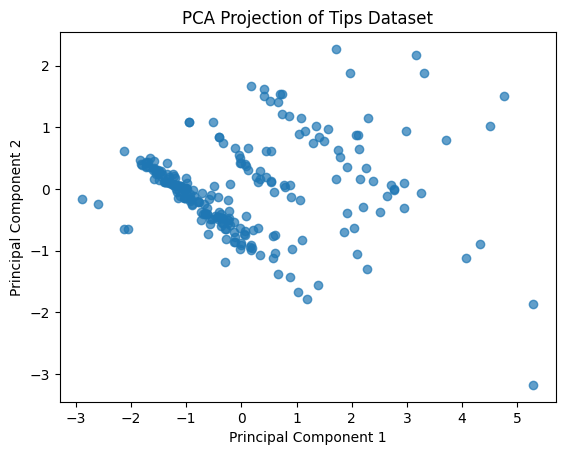

In [12]:
import matplotlib.pyplot as plt

plt.scatter(pca_df['PC1'], pca_df['PC2'], alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Projection of Tips Dataset')
plt.show()
